In [32]:
import pandas as pd
import numpy as np
import matplotlib.pyplot  as plt
import seaborn as sns
pd.set_option('display.max_columns', None)
%matplotlib inline
lot_a = pd.read_excel('KTP_task_datasets.xls', sheet_name='Lot A014', 
                      header=0, skiprows=[1], engine='xlrd')
lot_b = pd.read_excel('KTP_task_datasets.xls', sheet_name='Lot B025', 
                      header=0, skiprows=[1], engine='xlrd')
col_names = [
    'start_date', 'pull_date', 'set_down_day', 'exposure_days',
    'oven', 'temp_C', 'rh_pct', 'analyst',
    'assay_1', 'assay_2',
    'imp_092_1', 'imp_092_2',
    'imp_123_1', 'imp_123_2'
]
lot_a.columns = col_names
lot_b.columns = col_names
lot_a['formulation'] = 'A014'
lot_b['formulation'] = 'B025'
df = pd.concat([lot_a, lot_b], ignore_index=True)
df['temp_C'] = pd.to_numeric(df['temp_C'], errors='coerce')
df['rh_pct'] = pd.to_numeric(df['rh_pct'], errors='coerce')
df['assay_mean'] = df[['assay_1', 'assay_2']].mean(axis=1)
df['imp_092_mean'] = df[['imp_092_1', 'imp_092_2']].mean(axis=1)
df['imp_123_mean'] = df[['imp_123_1', 'imp_123_2']].mean(axis=1)



In [33]:
(df['set_down_day'] + df['exposure_days']).value_counts()

21    40
Name: count, dtype: int64

In [34]:
df['assay_diff'] = abs(df['assay_1'] - df['assay_2'])
df['imp092_diff'] = abs(df['imp_092_1'] - df['imp_092_2'])
df['imp123_diff'] = abs(df['imp_123_1'] - df['imp_123_2'])
df[['assay_diff','imp092_diff','imp123_diff']].describe()

,assay_diff,imp092_diff,imp123_diff
count,40.000000,40.000000,40.000000
mean,0.213675,0.019100,0.003475
std,0.162024,0.023341,0.002935
min,0.006000,0.000000,0.000000
25%,0.066000,0.004000,0.002000
50%,0.175500,0.012500,0.002000
75%,0.371750,0.025750,0.004000
max,0.519000,0.122000,0.014000


In [35]:
df['analyst'].value_counts()

analyst
CM     16
RG     14
SS     10
Name: count, dtype: int64

In [36]:
df['analyst'] = df['analyst'].str.strip()

In [37]:
print(" Missing values ")
print(df.isnull().sum())

 Missing values 
start_date       2
pull_date        2
set_down_day     0
exposure_days    0
oven             0
temp_C           2
rh_pct           2
analyst          0
assay_1          0
assay_2          0
imp_092_1        0
imp_092_2        0
imp_123_1        0
imp_123_2        0
formulation      0
assay_mean       0
imp_092_mean     0
imp_123_mean     0
assay_diff       0
imp092_diff      0
imp123_diff      0
dtype: int64


In [38]:
df[df['temp_C'].isna()]

,start_date,pull_date,set_down_day,exposure_days,oven,temp_C,rh_pct,analyst,assay_1,assay_2,imp_092_1,imp_092_2,imp_123_1,imp_123_2,formulation,assay_mean,imp_092_mean,imp_123_mean,assay_diff,imp092_diff,imp123_diff
19,NaT,NaT,21,0,n/a,NaN,NaN,SS,12.790,12.808,0.0,0.0,0.082,0.068,A014,12.7990,0.0,0.075,0.018,0.0,0.014
39,NaT,NaT,21,0,n/a,NaN,NaN,SS,12.493,12.720,0.0,0.0,0.143,0.143,B025,12.6065,0.0,0.143,0.227,0.0,0.000


In [39]:
df.groupby(['temp_C','rh_pct']).size()

temp_C  rh_pct
50.0    64.0      6
60.0    21.0      4
        42.0      4
        80.0      4
65.0    25.0      4
        63.0      4
70.0    11.0      4
        41.0      4
        79.0      4
dtype: int64

# Question 1: What are the key features of the dataset?
[Describe any observations regarding the structure, quality and characteristics of the data that you believe are relevant to the subsequent analysis.]

#####  1. Exposure duration and set-down day contain equivalent information (exposure_days = 21 − set_down_day), so only one is needed for modelling. Note that exposure_days is not constant across the dataset; it ranges from 1 to 21 days, with each temperature–humidity condition sampled at 2–3 different exposure times. This means the dataset effectively contains a time course at each stress condition, which is important for later modelling (see Q5).
##### 2. Duplicate laboratory measurements show good agreement, suggesting high analytical precision and low measurement variability.
##### 3.Measurements were generated by three analysts (RG, SS, CM), introducing a potential analyst effect that could contribute to measurement variability.
##### 4. Exactly 2 rows have missing dates, temperature, and humidity shown, but not a data quality problem. Two observations correspond to control samples that were not exposed to accelerated stability conditions. These records have exposure_days = 0, oven = "n/a", and missing temperature and humidity values.
##### 5.  The dataset is small, 19 stressed observations per formulation (excluding the control). This limits statistical power for modelling, particularly for interactions between temperature and humidity.
##### 6.  Temperature and humidity are not fully independent. Although several humidity levels were tested at 50, 60, 65 and 70°C, not all temperature–humidity combinations were explored. This limits the ability to completely separate temperature effects from humidity effects.
##### 7. The dataset is well balanced because each temperature–humidity–exposure time condition appears for both formulations (A014 and B025), enabling direct comparison of formulation performance under equivalent storage conditions.

# Question 2
##### 2. What insights can be gained from the available data?
##### Identify and communicate any trends, patterns or hypothetical relationships that you consider important. Where appropriate, support your conclusions using suitable visualisations and quantitative analyses. 


In [40]:
df_stressed = df[df['exposure_days'] > 0].copy() #(removing the control rows)
df_stressed['condition'] = (
    df_stressed['temp_C'].astype(int).astype(str) + "°C/" +
    df_stressed['rh_pct'].astype(int).astype(str) + "%RH/" +
    df_stressed['exposure_days'].astype(int).astype(str) + "d"
)
print("Total rows:", len(df))
print("Stressed rows:", len(df_stressed))
print("Control rows:", len(df) - len(df_stressed))
df_stressed[['formulation', 'condition', 'exposure_days',
             'assay_mean', 'imp_092_mean', 'imp_123_mean']].head() #(first 5 rows show)

Total rows: 40
Stressed rows: 38
Control rows: 2


,formulation,condition,exposure_days,assay_mean,imp_092_mean,imp_123_mean
0,A014,70°C/11%RH/21d,21,8.1520,0.2850,0.074
1,A014,65°C/25%RH/21d,21,10.9430,0.2305,0.135
2,A014,50°C/64%RH/21d,21,12.1690,0.2220,0.190
3,A014,60°C/80%RH/21d,21,11.3065,0.6620,0.169
4,A014,60°C/42%RH/21d,21,11.5535,0.5340,0.176


In [41]:
df_stressed.groupby('formulation').size()

formulation
A014    19
B025    19
dtype: int64

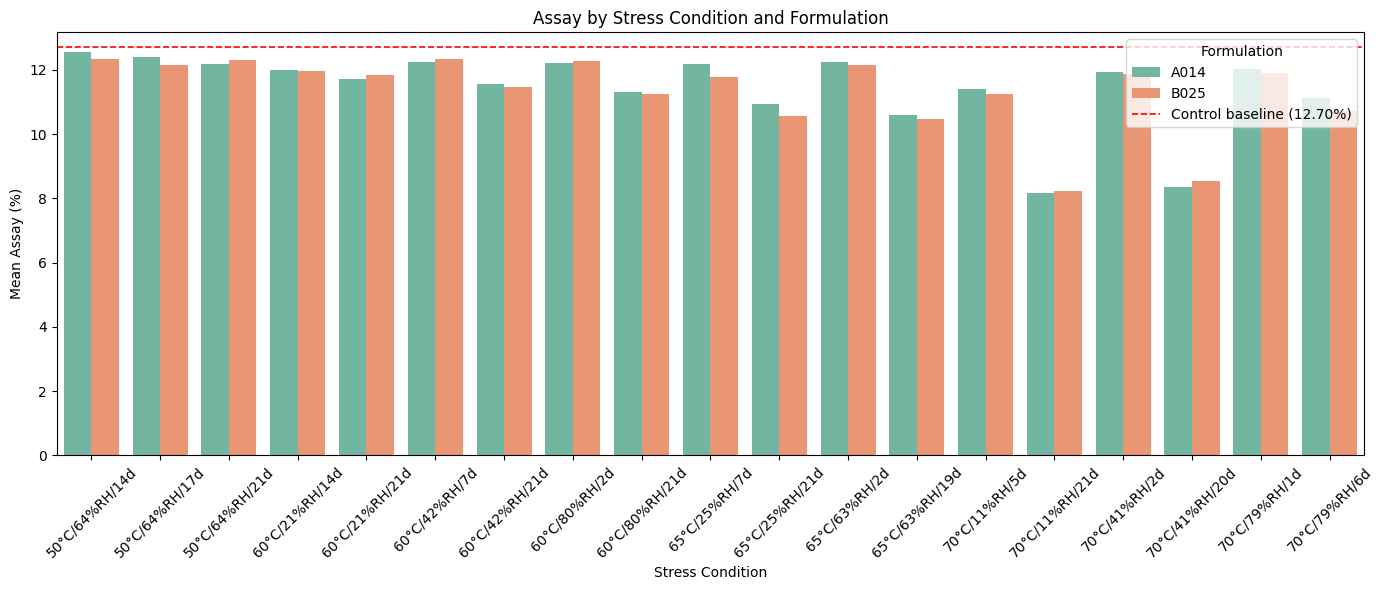

In [42]:
fig, ax = plt.subplots(figsize=(14, 6))
control_assay = df[df['exposure_days'] == 0]['assay_mean'].mean()
condition_order = (
    df_stressed[['condition','temp_C','rh_pct','exposure_days']]
    .drop_duplicates()
    .sort_values(['temp_C','rh_pct','exposure_days'])
    ['condition']
)
sns.barplot(
    data=df_stressed,
    x='condition', y='assay_mean',
    hue='formulation',
    order=condition_order,
    palette='Set2', ax=ax
)
ax.axhline(control_assay, color='red', linestyle='--', linewidth=1.2, label=f'Control baseline ({control_assay:.2f}%)')
ax.set_title('Assay by Stress Condition and Formulation')
ax.set_xlabel('Stress Condition')
ax.set_ylabel('Mean Assay (%)')
ax.legend(title='Formulation')
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

##### All stressed samples show assay loss relative to the unstressed control (12.70%).

##### Assay generally decreases under more severe stress conditions. Lower assay values are observed at higher temperatures and longer exposure durations, with several 70°C conditions exhibiting the greatest active ingredient loss.

##### Direct comparison of humidity effects is difficult from this chart because different humidity levels were sampled at different exposure durations. Consequently, the separate contributions of temperature, humidity and exposure time cannot be isolated from this visualisation alone.

##### Both formulations behave similarly across all conditions at this stage of analysis.

##### The largest assay losses occur under several high-temperature, long-exposure conditions, suggesting that both temperature and exposure duration contribute to degradation.

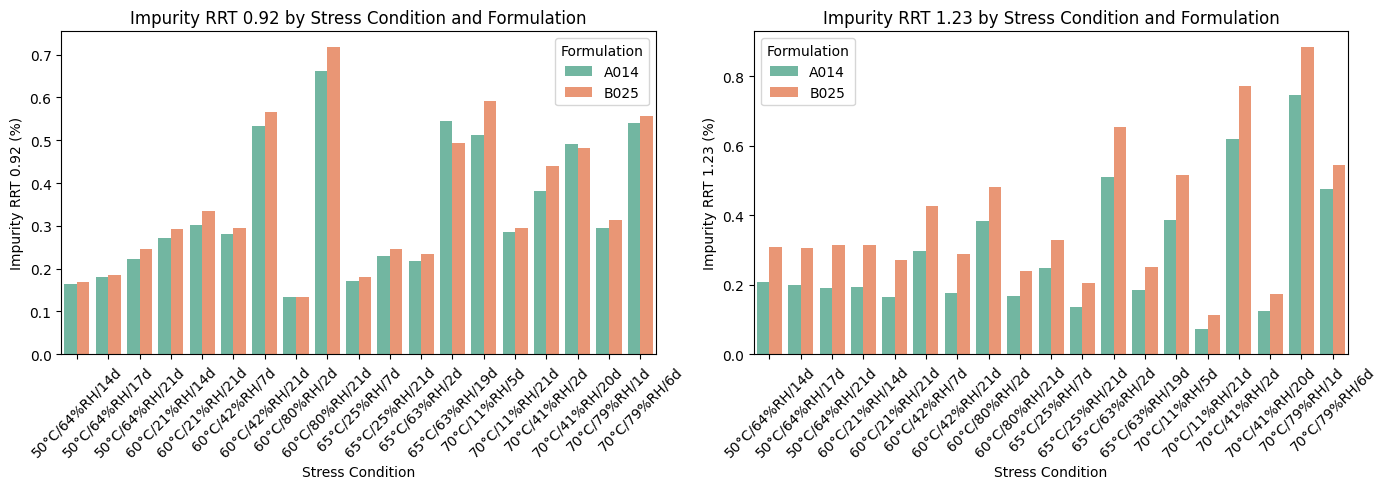

In [43]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, col, title in zip(
    axes,
    ['imp_092_mean', 'imp_123_mean'],
    ['Impurity RRT 0.92', 'Impurity RRT 1.23']
):
    sns.barplot(
        data=df_stressed,
        x='condition', y=col,
        hue='formulation',
        order=condition_order,
        palette='Set2', ax=ax
    )
    ax.set_title(f'{title} by Stress Condition and Formulation')
    ax.set_xlabel('Stress Condition')
    ax.set_ylabel(f'{title} (%)')
    ax.legend(title='Formulation')
    ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

##### Both impurities increase under stressed storage, consistent with accelerated degradation, but they appear to respond to different drivers. Impurity RRT 1.23 shows a clear joint dependence on temperature and exposure time: at 21-day exposure it rises steadily from ~0.2-0.3% at 50°C to ~0.7-0.85% at 70°C, while short-exposure samples remain low across all temperatures. Impurity RRT 0.92 shows a less consistent time dependence — some of its highest levels occur under high-humidity conditions even at short exposure (e.g. 60°C/80%RH/2d, 65°C/63%RH), suggesting relative humidity may be a more important driver for this particular degradation pathway. Both formulations show broadly similar qualitative patterns for both impurities, with B025 tending toward somewhat higher levels under the most severe (high-temperature, long-exposure) conditions, explored further in Question 4.

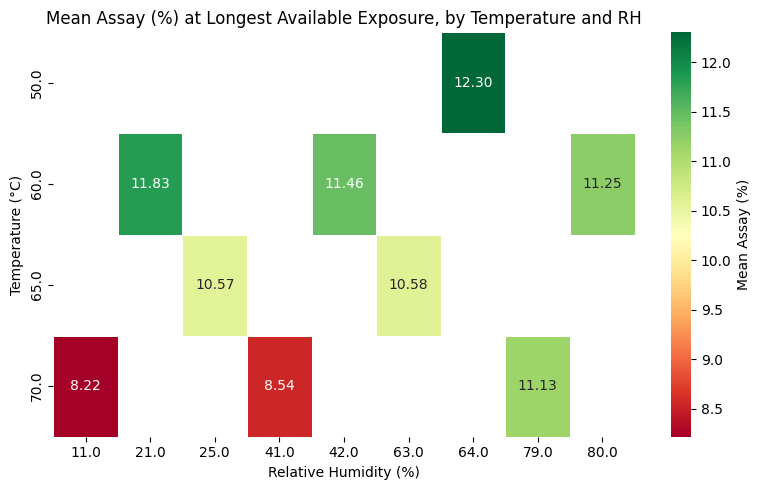

In [44]:
heatmap_data = (
    df_stressed
    .sort_values('exposure_days')
    .groupby(['temp_C', 'rh_pct'])
    .tail(1)
    .groupby(['temp_C', 'rh_pct'])['assay_mean']
    .mean()
    .round(3)
    .unstack('rh_pct')
)
fig, ax = plt.subplots(figsize=(8, 5))
sns.heatmap(
    heatmap_data,
    annot=True, fmt='.2f',
    cmap='RdYlGn',
    ax=ax,
    linewidths=0.5,
    cbar_kws={'label': 'Mean Assay (%)'}
)
ax.set_title('Mean Assay (%) at Longest Available Exposure, by Temperature and RH')
ax.set_xlabel('Relative Humidity (%)')
ax.set_ylabel('Temperature (°C)')
plt.tight_layout()
plt.show()

##### The heatmap shows assay decreasing steadily with temperature: from 12.30% at 50°C/64%RH, to 11.25-11.83% across the 60°C conditions, to ~10.6% at 65°C, down to 8.2-8.5% at 70°C/11%RH and 70°C/41%RH. Within a given temperature, the spread across humidity levels is comparatively small (e.g. 11.25-11.83% across the three 60°C conditions), suggesting temperature is the dominant driver, consistent with Q3. The 70°C/79%RH cell (11.13%) appears anomalously high relative to the other 70°C conditions, but this reflects its much shorter exposure time (6 days vs 19-21 days for the other cells shown) rather than a protective effect of humidity, a reminder that exposure time must be considered alongside temperature and humidity when interpreting this dataset. The sparse, non-rectangular shape of the heatmap itself illustrates the incomplete temperature-humidity factorial design noted in Q1.

### The insights
##### 1. Assay decreases under stressed conditions, driven by both temperature and exposure time.
##### 2. Temperature and exposure duration together appear to be the primary drivers of assay loss; humidity's effect is comparatively small once these are accounted for.
##### 3. Impurities increase as degradation progresses.
##### 4. Impurity RRT 1.23 tracks temperature and exposure time closely, while Impurity RRT 0.92 appears more sensitive to humidity.
##### 5. The incomplete temperature-humidity factorial design limits how cleanly individual effects can be separated.
##### 6. The two formulations appear broadly similar descriptively, though B025 trends slightly higher on impurities under the most severe conditions.

# Question 3

In [45]:
control_assay_by_formulation = (
    df[df['exposure_days'] == 0]
    .set_index('formulation')['assay_mean']
)
df_stressed['control_assay'] = df_stressed['formulation'].map(control_assay_by_formulation)
df_stressed['assay_loss'] = df_stressed['control_assay'] - df_stressed['assay_mean']
df_stressed['total_impurity'] = (
    df_stressed['imp_092_mean'] + df_stressed['imp_123_mean']
)
df_stressed[['formulation', 'condition', 'assay_mean',
             'control_assay', 'assay_loss',
             'imp_092_mean', 'imp_123_mean',
             'total_impurity']].head()

,formulation,condition,assay_mean,control_assay,assay_loss,imp_092_mean,imp_123_mean,total_impurity
0,A014,70°C/11%RH/21d,8.1520,12.799,4.6470,0.2850,0.074,0.3590
1,A014,65°C/25%RH/21d,10.9430,12.799,1.8560,0.2305,0.135,0.3655
2,A014,50°C/64%RH/21d,12.1690,12.799,0.6300,0.2220,0.190,0.4120
3,A014,60°C/80%RH/21d,11.3065,12.799,1.4925,0.6620,0.169,0.8310
4,A014,60°C/42%RH/21d,11.5535,12.799,1.2455,0.5340,0.176,0.7100


In [46]:
df_stressed[['assay_loss', 'imp_092_mean', 'imp_123_mean', 'total_impurity']].describe().round(3)

,assay_loss,imp_092_mean,imp_123_mean,total_impurity
count,38.000,38.000,38.000,38.000
mean,1.324,0.347,0.339,0.686
std,1.202,0.162,0.199,0.255
min,0.259,0.134,0.074,0.359
25%,0.567,0.224,0.191,0.468
50%,0.818,0.296,0.292,0.616
75%,1.622,0.492,0.464,0.880
max,4.647,0.718,0.885,1.212


In [47]:
from scipy.stats import spearmanr
rho, p = spearmanr(df_stressed['temp_C'], df_stressed['assay_loss'])

print(f"Spearman rho = {rho:.3f}")
print(f"p-value = {p:.4f}")

Spearman rho = 0.657
p-value = 0.0000


In [48]:
rho_t, p_t = spearmanr(df_stressed['exposure_days'], df_stressed['assay_loss'])
print(f"Spearman rho = {rho_t:.3f}")
print(f"p-value = {p_t:.4f}")

Spearman rho = 0.372
p-value = 0.0214


##### Exposure time also shows a significant positive association with assay loss (Spearman ρ = 0.372, p = 0.021), as expected for a degradation process. However, this correlation is weaker than temperature's (ρ = 0.657), since exposure time and temperature were not designed to vary independently of each other, their combined effect is examined jointly in the regression model in Question 5.

<Axes: xlabel='temp_C', ylabel='assay_loss'>

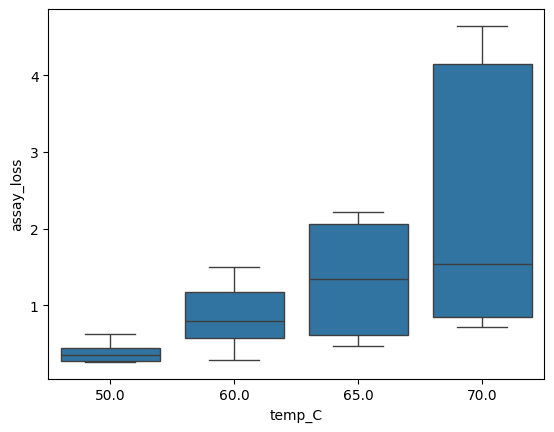

In [49]:
sns.boxplot(
    data=df_stressed,
    x='temp_C',
    y='assay_loss'
)

##### Temperature shows a strong positive association with assay loss (Spearman ρ = 0.657, p < 0.0001). Higher temperatures are associated with greater active ingredient degradation, with the largest assay losses occurring at 70°C. Although considerable variability exists within each temperature level, some of this variation may be attributable to differences in relative humidity among the tested conditions. Overall, temperature appears to be a major driver of product degradation in this study.

In [50]:
rho_rh, p_rh = spearmanr(
    df_stressed['rh_pct'],
    df_stressed['assay_loss']
)
print(f"Spearman rho = {rho_rh:.3f}")
print(f"p-value = {p_rh:.4f}")

Spearman rho = -0.362
p-value = 0.0255


##### Relative humidity shows a weaker association with assay loss than temperature (Spearman ρ = −0.362, p = 0.026). Interpretation is complicated by the experimental design, since not all temperature–humidity combinations were tested. Consequently, the apparent humidity effect may partly reflect confounding with temperature. Based on the available evidence, temperature appears to be the dominant degradation driver, while humidity may play a secondary role.

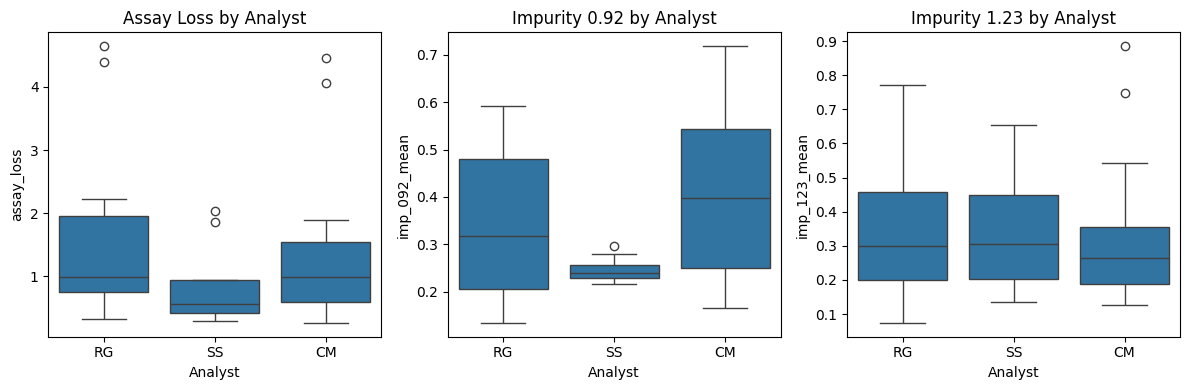

analyst
CM    16
RG    14
SS     8
Name: count, dtype: int64


In [51]:
fig, axes = plt.subplots(1, 3, figsize=(12, 4))
for ax, col, title in zip(
    axes,
    ['assay_loss', 'imp_092_mean', 'imp_123_mean'],
    ['Assay Loss', 'Impurity 0.92', 'Impurity 1.23']
):
    sns.boxplot(data=df_stressed, x='analyst', y=col, ax=ax)
    ax.set_title(f'{title} by Analyst')
    ax.set_xlabel('Analyst')
    ax.set_ylabel(col)
plt.tight_layout()
plt.show()
print(df_stressed['analyst'].value_counts()) #sample

# Summary

##### Measurements were performed by three analysts (CM = 16, RG = 14, SS = 8). Visual inspection suggests broadly similar distributions across analysts for assay loss and Impurity RRT 1.23. Impurity RRT 0.92 appears somewhat lower for analyst SS, although this may reflect differences in the storage conditions assigned to each analyst rather than a genuine analyst effect. Given the small and unequal sample sizes, together with the non-random allocation of conditions, a reliable assessment of analyst effects is not possible from the available data. Analyst identity should therefore be regarded as a potential source of uncontrolled variability in any subsequent modelling.

### Limitations include:
##### 1.While the study covers a single overall timeframe, samples were exposed for varying durations (1-21 days) depending on condition, giving a limited time-course at each stress condition. This supports the exposure-time effect identified above, though with only 2-3 time points per condition, degradation rate estimates remain approximate.
##### 2. Analyst identity represents a potential source of variability. However, the small and unequal sample sizes, together with the non-random allocation of storage conditions to analysts, prevent a reliable assessment of analyst effects.
##### 3. Temperature and relative humidity were not fully crossed experimentally, meaning that not all temperature–humidity combinations were tested. As a result, the individual contributions of temperature and humidity cannot be completely separated.

# Question 4



In [52]:
matched = df_stressed.pivot_table(
    index=['condition', 'temp_C', 'rh_pct', 'exposure_days'],
    columns='formulation',
    values=['assay_loss', 'imp_092_mean', 'imp_123_mean', 'total_impurity']
)
matched.columns = ['_'.join(col) for col in matched.columns]
matched = matched.reset_index()
# Difference defined as B025 - A014
matched['assay_loss_diff_B_minus_A'] = matched['assay_loss_B025'] - matched['assay_loss_A014']
matched['imp_092_diff_B_minus_A'] = matched['imp_092_mean_B025'] - matched['imp_092_mean_A014']
matched['imp_123_diff_B_minus_A'] = matched['imp_123_mean_B025'] - matched['imp_123_mean_A014']
matched['total_impurity_diff_B_minus_A'] = matched['total_impurity_B025'] - matched['total_impurity_A014']
matched[['condition',
         'assay_loss_A014', 'assay_loss_B025', 'assay_loss_diff_B_minus_A',
         'imp_092_mean_A014', 'imp_092_mean_B025', 'imp_092_diff_B_minus_A',
         'imp_123_mean_A014', 'imp_123_mean_B025', 'imp_123_diff_B_minus_A',
         'total_impurity_A014', 'total_impurity_B025', 'total_impurity_diff_B_minus_A']]

,condition,assay_loss_A014,assay_loss_B025,assay_loss_diff_B_minus_A,imp_092_mean_A014,imp_092_mean_B025,imp_092_diff_B_minus_A,imp_123_mean_A014,imp_123_mean_B025,imp_123_diff_B_minus_A,total_impurity_A014,total_impurity_B025,total_impurity_diff_B_minus_A
0,50°C/64%RH/14d,0.2600,0.2590,-0.0010,0.1650,0.1680,0.0030,0.2090,0.308,0.0990,0.3740,0.4760,0.1020
1,50°C/64%RH/17d,0.3990,0.4510,0.0520,0.1810,0.1860,0.0050,0.1990,0.307,0.1080,0.3800,0.4930,0.1130
2,50°C/64%RH/21d,0.6300,0.3070,-0.3230,0.2220,0.2470,0.0250,0.1900,0.314,0.1240,0.4120,0.5610,0.1490
3,60°C/21%RH/14d,0.8115,0.6465,-0.1650,0.2710,0.2920,0.0210,0.1935,0.313,0.1195,0.4645,0.6050,0.1405
4,60°C/21%RH/21d,1.0955,0.7810,-0.3145,0.3015,0.3355,0.0340,0.1645,0.270,0.1055,0.4660,0.6055,0.1395
5,60°C/42%RH/21d,1.2455,1.1480,-0.0975,0.5340,0.5665,0.0325,0.1760,0.289,0.1130,0.7100,0.8555,0.1455
6,60°C/42%RH/7d,0.5510,0.2830,-0.2680,0.2805,0.2960,0.0155,0.2960,0.428,0.1320,0.5765,0.7240,0.1475
7,60°C/80%RH/21d,1.4925,1.3600,-0.1325,0.6620,0.7185,0.0565,0.1690,0.240,0.0710,0.8310,0.9585,0.1275
8,60°C/80%RH/2d,0.5745,0.3240,-0.2505,0.1340,0.1345,0.0005,0.3840,0.481,0.0970,0.5180,0.6155,0.0975
9,65°C/25%RH/21d,1.8560,2.0370,0.1810,0.2305,0.2460,0.0155,0.1350,0.206,0.0710,0.3655,0.4520,0.0865


In [53]:
matched[['assay_loss_diff_B_minus_A',
         'imp_092_diff_B_minus_A',
         'imp_123_diff_B_minus_A',
         'total_impurity_diff_B_minus_A']].describe().round(3)

,assay_loss_diff_B_minus_A,imp_092_diff_B_minus_A,imp_123_diff_B_minus_A,total_impurity_diff_B_minus_A
count,19.000,19.000,19.000,19.000
mean,-0.103,0.019,0.101,0.119
std,0.178,0.028,0.033,0.053
min,-0.386,-0.053,0.039,0.013
25%,-0.253,0.006,0.071,0.087
50%,-0.104,0.017,0.106,0.127
75%,-0.018,0.029,0.128,0.148
max,0.224,0.079,0.154,0.212


In [54]:
# Count conditions where B025 is worse (positive difference)
print("Assay loss:")
print((matched['assay_loss_diff_B_minus_A'] > 0).sum(),
      "of",
      len(matched))
print("\nImpurity 0.92:")
print((matched['imp_092_diff_B_minus_A'] > 0).sum(),
      "of",
      len(matched))
print("\nImpurity 1.23:")
print((matched['imp_123_diff_B_minus_A'] > 0).sum(),
      "of",
      len(matched))
print("\nTotal impurity:")
print((matched['total_impurity_diff_B_minus_A'] > 0).sum(),
      "of",
      len(matched))

Assay loss:
4 of 19

Impurity 0.92:
17 of 19

Impurity 1.23:
19 of 19

Total impurity:
19 of 19


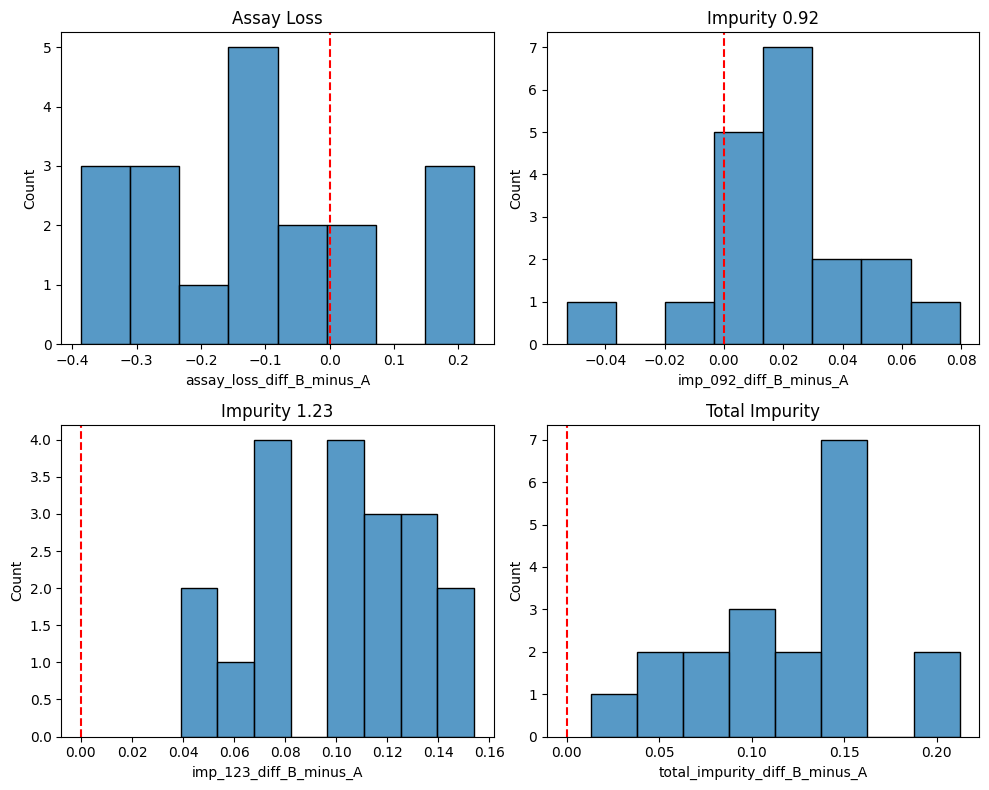

In [55]:
fig, axes = plt.subplots(2,2, figsize=(10,8))
metrics = [
    ('assay_loss_diff_B_minus_A', 'Assay Loss'),
    ('imp_092_diff_B_minus_A', 'Impurity 0.92'),
    ('imp_123_diff_B_minus_A', 'Impurity 1.23'),
    ('total_impurity_diff_B_minus_A', 'Total Impurity')
]
for ax, (col, title) in zip(axes.flatten(), metrics):
    sns.histplot(matched[col], bins=8, ax=ax)
    ax.axvline(0, color='red', linestyle='--')
    ax.set_title(title)
plt.tight_layout()
plt.show()

The assay loss difference is small and inconsistent, not meaningful
B025 accumulates more impurities than A014 under every single tested condition, driven primarily by imp_123

In [56]:
summary = pd.DataFrame({
    'Metric': ['Assay Loss', 'Impurity 0.92', 'Impurity 1.23', 'Total Impurity'],
    'Mean Difference (B025 - A014)': [
        matched['assay_loss_diff_B_minus_A'].mean(),
        matched['imp_092_diff_B_minus_A'].mean(),
        matched['imp_123_diff_B_minus_A'].mean(),
        matched['total_impurity_diff_B_minus_A'].mean()
    ]
})

summary

,Metric,Mean Difference (B025 - A014)
0,Assay Loss,-0.103237
1,Impurity 0.92,0.018632
2,Impurity 1.23,0.100553
3,Total Impurity,0.119184


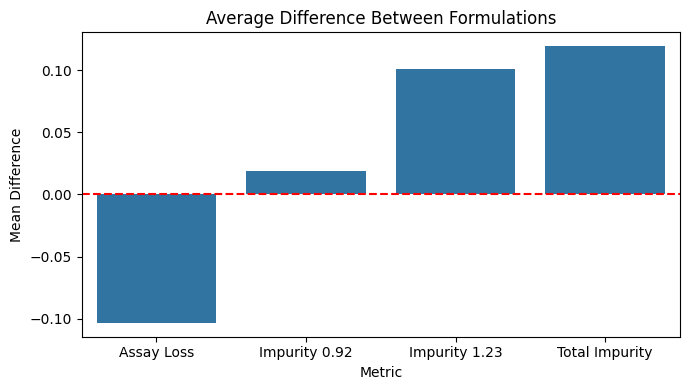

In [57]:
plt.figure(figsize=(7,4))
sns.barplot(
    data=summary,
    x='Metric',
    y='Mean Difference (B025 - A014)'
)
plt.axhline(0, color='red', linestyle='--')
plt.ylabel('Mean Difference')
plt.title('Average Difference Between Formulations')
plt.tight_layout()
plt.show()

The evidence suggests:

B025

Slightly better assay retention (~0.10 units lower assay loss).
Consistently higher impurity burden.

A014

Slightly worse assay retention.
Consistently lower impurity burden.

In pharmaceutical stability work, impurity growth is often the more critical stability concern because degradation products frequently determine specification limits.

In [58]:
matched[['assay_loss_diff_B_minus_A',
         'imp_092_diff_B_minus_A',
         'imp_123_diff_B_minus_A',
         'total_impurity_diff_B_minus_A']].round(3)

,assay_loss_diff_B_minus_A,imp_092_diff_B_minus_A,imp_123_diff_B_minus_A,total_impurity_diff_B_minus_A
0,-0.001,0.003,0.099,0.102
1,0.052,0.005,0.108,0.113
2,-0.323,0.025,0.124,0.149
3,-0.165,0.021,0.120,0.140
4,-0.314,0.034,0.106,0.140
5,-0.098,0.032,0.113,0.145
6,-0.268,0.016,0.132,0.147
7,-0.133,0.056,0.071,0.127
8,-0.250,0.001,0.097,0.097
9,0.181,0.016,0.071,0.086


In [59]:
# Largest B025 advantage in assay retention
matched.loc[
    matched['assay_loss_diff_B_minus_A'].idxmin(),
    ['condition', 'assay_loss_diff_B_minus_A']
]
# Largest B025 disadvantage in total impurity
matched.loc[
    matched['total_impurity_diff_B_minus_A'].idxmax(),
    ['condition', 'total_impurity_diff_B_minus_A']
]

condition                        70°C/41%RH/2d
total_impurity_diff_B_minus_A           0.2125
Name: 16, dtype: object

# Summary

##### The available evidence suggests that A014 is the more stable formulation overall. Although B025 exhibits slightly lower assay loss on average (mean difference = −0.103), it consistently generates higher levels of degradation products. Impurity RRT 1.23 was higher for B025 under all 19 matched stress conditions, while total impurity was also higher in all 19 conditions. This pattern is considerably more consistent than the modest assay-retention advantage observed for B025.

##### From a stability perspective, the impurity profile is therefore the key differentiating factor between the formulations. Based on the available data, A014 would be recommended for further development because it demonstrates a consistently lower degradation-product burden across the tested storage conditions.

##### However, this recommendation should be considered provisional. The dataset is small, exposure durations varied across conditions (1-21 days) with only 2-3 time points per condition, and temperature and humidity were not fully crossed experimentally. Additional stability studies with more time points per condition would be required to confirm the long-term relative performance of the two formulations.

# Question 5

##### Key constraint: The dataset has only 38 stressed observations, one time point, and an incomplete factorial design. Any model must be appropriate for this scale.

#### 1. Multiple Linear Regression

Purpose: quantify effects of temperature, humidity, formulation

Strengths:

 1. interpretable
 2. aligned with dataset size

Limitations:

 1. assumes linear relationships
 2. confounding between temp and RH



#### 2.  Arrhenius-Inspired Temperature Analysis

Purpose: explore whether degradation follows expected kinetic behaviour

Strengths:

 1. scientifically grounded
 2. common pharmaceutical stability framework

Limitations:

 1. only 2–3 time points per condition
 2. cannot estimate rate constants or activation energy

In [60]:
!pip install statsmodels


[notice] A new release of pip is available: 25.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [62]:
import statsmodels.formula.api as smf
model1 = smf.ols(
    'assay_loss ~ temp_C + rh_pct + exposure_days + C(formulation)',
    data=df_stressed
).fit()
print(model1.summary())

                            OLS Regression Results                            
Dep. Variable:             assay_loss   R-squared:                       0.769
Model:                            OLS   Adj. R-squared:                  0.741
Method:                 Least Squares   F-statistic:                     27.48
Date:                Sat, 13 Jun 2026   Prob (F-statistic):           4.29e-10
Time:                        22:22:02   Log-Likelihood:                -32.559
No. Observations:                  38   AIC:                             75.12
Df Residuals:                      33   BIC:                             83.31
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                             coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------------
Intercept                 -9

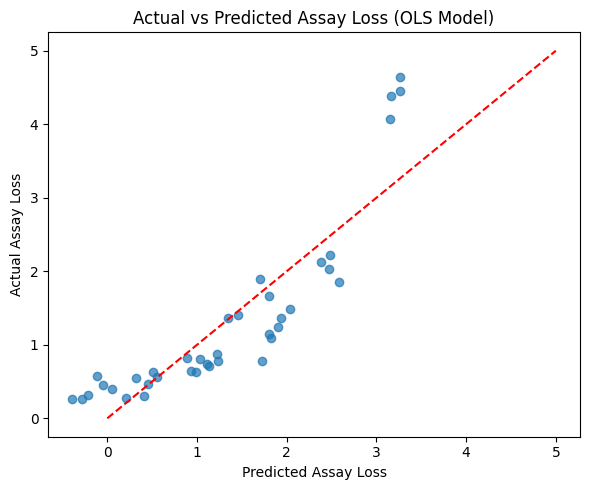

In [64]:
fig, ax = plt.subplots(figsize=(6,5))
ax.scatter(model1.fittedvalues, model1.model.endog, alpha=0.7)
ax.plot([0,5],[0,5], 'r--')
ax.set_xlabel('Predicted Assay Loss')
ax.set_ylabel('Actual Assay Loss')
ax.set_title('Actual vs Predicted Assay Loss (OLS Model)')
plt.tight_layout()
plt.show()

# Summary

##### A multiple linear regression model was fitted to quantify the effects of temperature, relative humidity, exposure time, and formulation on assay loss. The model explained approximately 77% of the observed variability (R² = 0.769), substantially more than a model excluding exposure time (R² = 0.342). Both temperature (β = 0.147, p < 0.001) and exposure time (β = 0.113, p < 0.001) were highly significant predictors, confirming that assay loss increases with both higher temperature and longer exposure. Relative humidity and formulation remained non-significant after accounting for the other variables. These results reinforce and substantially strengthen the conclusion from Question 3 that temperature is a major degradation driver, while also showing that exposure time is at least as important and was a key missing variable in the simpler model. The model remains limited by the small sample size, the incomplete temperature-humidity design, and some residual confounding between temperature and exposure time (the model's condition number is relatively high, suggesting some multicollinearity among predictors)

##### The actual vs predicted plot confirms broadly good fit across the mid-range of assay loss values, though the model tends to underpredict degradation at the most extreme conditions (actual loss > 4%) and produces marginally negative predictions near the control baseline — expected limitations of a linear model applied to a small, bounded dataset.

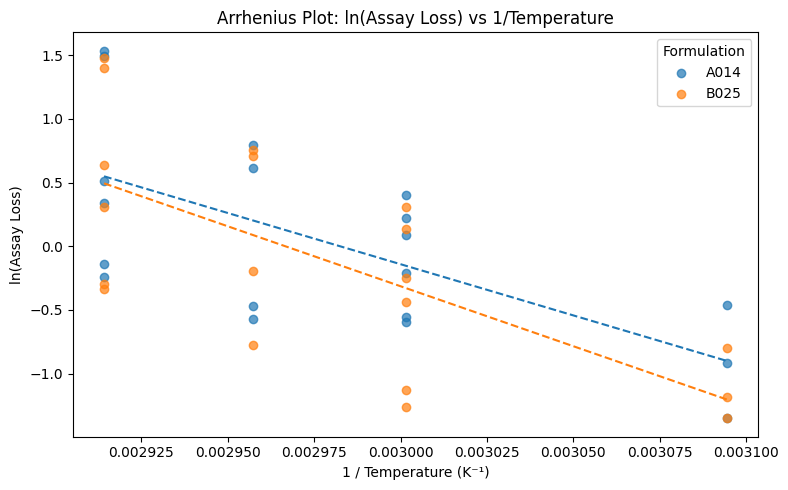

In [63]:
# Model 2: Arrhenius-inspired temperature analysis
# Convert temperature to Kelvin
df_stressed['temp_K'] = df_stressed['temp_C'] + 273.15
df_stressed['inv_temp_K'] = 1 / df_stressed['temp_K']
df_stressed['ln_assay_loss'] = np.log(df_stressed['assay_loss'])
# Plot ln(assay_loss) vs 1/T for each formulation
fig, ax = plt.subplots(figsize=(8, 5))
for formulation, group in df_stressed.groupby('formulation'):
    ax.scatter(
        group['inv_temp_K'],
        group['ln_assay_loss'],
        label=formulation,
        alpha=0.7
    )
    # Fit a line through the points
    coeffs = np.polyfit(group['inv_temp_K'], group['ln_assay_loss'], 1)
    x_line = np.linspace(group['inv_temp_K'].min(),
                         group['inv_temp_K'].max(), 100)
    ax.plot(x_line, np.polyval(coeffs, x_line), linestyle='--')
ax.set_xlabel('1 / Temperature (K⁻¹)')
ax.set_ylabel('ln(Assay Loss)')
ax.set_title('Arrhenius Plot: ln(Assay Loss) vs 1/Temperature')
ax.legend(title='Formulation')
plt.tight_layout()
plt.show()

# Summary

##### An Arrhenius-inspired temperature analysis was explored to assess whether degradation exhibits the temperature dependence expected from chemical reaction kinetics. The plot showed a broadly negative relationship between ln(assay loss) and 1/temperature, consistent with greater degradation at higher temperatures. Unlike a true single-timepoint study, most stress conditions here do include two time points (typically 2-6 days apart from 21 days), which in principle allows a rough zero-order degradation rate to be estimated for each condition (e.g., as Δassay/Δexposure_days). However, with only 2 points per condition, these rate estimates carry no information about linearity, lack any uncertainty estimate, and activation energies derived from them (via a full Arrhenius fit across temperatures) would be highly uncertain. The analysis should therefore be considered indicative rather than predictive, a more robust kinetic/shelf-life model would require 3+ time points per condition.

# Question 6

### Key limitations of the dataset

1. **Small sample size**
The dataset contains only 38 stressed observations, with 19 matched stress conditions per formulation. This limits statistical power and makes it difficult to assess interactions or fit complex models.

2. **Limited time-course per condition**
While exposure times vary (1–21 days) across conditions, each condition typically has only 2–3 time points. This allows rough degradation-rate estimates (as used in the regression and Arrhenius-style analyses) but is insufficient for reliable shelf-life prediction or full kinetic modelling, which would require more time points per condition.

3. **Incomplete temperature–humidity design**
Not all temperature and relative humidity combinations were tested. This makes it difficult to separate the individual effects of temperature and humidity.

4. **Limited replication**
Each formulation-condition combination appears only once after averaging duplicate analytical measurements. This means biological/process variability cannot be separated from condition effects.

5. **Potential analyst effect**
Measurements were performed by three analysts with unequal sample sizes. Analyst identity may introduce uncontrolled variability, but the dataset is too small to assess this reliably.

6. **Only two formulations**
Only A014 and B025 were tested, so conclusions are limited to these prototypes and may not generalise to other formulations.

### Recommended improvements for future studies

1. **Increase the number of time points per condition (highest priority)**

The current design already varies exposure time (1–21 days), but with only 2–3 points per condition. Adding more time points (e.g. 7, 14, 21, 42, 84 days) for each temperature/humidity condition would substantially improve degradation-rate estimates, support shelf-life prediction, and enable a proper Arrhenius analysis.

2. **Use a fully crossed temperature–humidity design**

All combinations of temperature and relative humidity should be tested (for example 50°C, 60°C, 65°C and 70°C crossed with several humidity levels). This would allow the independent effects of temperature and humidity, as well as their interaction, to be quantified.

3. **Increase replication**

Additional replicate samples should be included for each formulation-condition combination. This would improve statistical power and allow experimental variability to be estimated more reliably.

4. **Randomise analyst allocation**

Samples should be assigned randomly to analysts, or analyst identity should be balanced across conditions. This would reduce the risk of analyst-specific measurement bias.

5. **Expand the range of formulations**

Testing additional prototype formulations would provide a broader understanding of formulation stability and help identify the characteristics associated with improved performance.

## Conclusion

##### The dataset was sufficient to identify broad degradation patterns and compare the two prototype formulations under accelerated stability conditions. However, interpretation is limited by the small sample size, the limited number of time points per condition, the incomplete temperature–humidity design, and potential analyst effects. The highest priority for future studies would be adding more time points per condition, as this would enable more reliable degradation rate estimates, shelf-life predictions, and more robust kinetic modelling. A fully crossed temperature–humidity design with additional replication would further improve the ability to separate environmental effects and quantify uncertainty. These improvements would provide a stronger basis for formulation selection and long-term stability assessment.